# 1D-CNN v4 — Proven v2 Setup + Adaptation

Pakai v2 setup that worked (Z-score norm, mixup, noise). Tambah fine-tune adaptation per scenario.

In [1]:
import sys, math, copy
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from config import (
    MODELS_DIR, FIGURES_DIR, RANDOM_SEED, N_CLASSES, get_device,
    SUBJECTS_NON_FATIGUE, SUBJECTS_FATIGUE, SUBJECTS_INTERDAY_LONG,
)
from src.data_splitter import (
    load_metadata, load_windows_from_metadata,
    compute_normalization_stats, apply_normalization,
    scenario_1_ideal, scenario_4_interday, scenario_5_fatigue,
)
from src.evaluation import print_report, plot_confusion_matrix, measure_latency, print_latency

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = get_device()
META = load_metadata()
print(f"Device: {DEVICE}")

Device: mps


## Model (same as v2)

In [2]:
class ECA1d(nn.Module):
    def __init__(self, ch):
        super().__init__()
        k = max(int(abs(math.log2(ch)/2 + 0.5)), 3)
        k = k if k % 2 else k + 1
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=k//2, bias=False)
    def forward(self, x):
        b, c, t = x.size()
        w = self.gap(x).view(b, 1, c)
        return x * torch.sigmoid(self.conv(w)).view(b, c, 1).expand_as(x)

class SepConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, k=5, p=2):
        super().__init__()
        self.dw = nn.Conv1d(in_ch, in_ch, k, padding=p, groups=in_ch)
        self.pw = nn.Conv1d(in_ch, out_ch, 1)
    def forward(self, x): return self.pw(self.dw(x))

class TemporalSCNN(nn.Module):
    def __init__(self, in_ch=8, n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_ch, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), ECA1d(64), nn.MaxPool1d(2),
            SepConv1d(64, 128, 5, 2), nn.BatchNorm1d(128), nn.ReLU(), ECA1d(128), nn.MaxPool1d(2),
            SepConv1d(128, 256, 3, 1), nn.BatchNorm1d(256), nn.ReLU(), ECA1d(256), nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, 64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64, n_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))

print(f"Parameters: {sum(p.numel() for p in TemporalSCNN().parameters()):,}")

Parameters: 62,676


## Training utilities (same as v2)

In [3]:
def circular_augment(X, y, n_rot=8):
    N, C, T = X.shape
    Xa = np.empty((N * n_rot, C, T), dtype=X.dtype)
    ya = np.empty(N * n_rot, dtype=y.dtype)
    for s in range(n_rot):
        Xa[s*N:(s+1)*N] = np.roll(X, shift=s, axis=1)
        ya[s*N:(s+1)*N] = y
    idx = np.random.RandomState(RANDOM_SEED).permutation(len(ya))
    return Xa[idx], ya[idx]


class MixupDataset(Dataset):
    def __init__(self, X, y, alpha=0.2, noise_std=0.1):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.alpha = alpha
        self.noise_std = noise_std
        self.n = len(y)
    def __len__(self): return self.n
    def __getitem__(self, idx):
        x, y1 = self.X[idx].clone(), self.y[idx]
        if self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std
        if self.alpha > 0 and torch.rand(1).item() < 0.5:
            idx2 = torch.randint(0, self.n, (1,)).item()
            lam = np.random.beta(self.alpha, self.alpha)
            x2 = self.X[idx2]
            if self.noise_std > 0: x2 = x2 + torch.randn_like(x2) * self.noise_std
            x = lam * x + (1 - lam) * x2
            y1 = y1 if lam >= 0.5 else self.y[idx2]
        return x, y1


def make_loader(X, y, augment=True, batch_size=256):
    if augment:
        ds = MixupDataset(X, y)
    else:
        ds = TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(y).long())
    return DataLoader(ds, batch_size=batch_size, shuffle=True)


def train_model(model, loader, n_epochs=50, lr=3e-3):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, epochs=n_epochs, steps_per_epoch=len(loader))
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    for ep in range(n_epochs):
        model.train()
        loss_sum, correct, total = 0, 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = crit(out, yb)
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
            loss_sum += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
        if (ep+1) % 10 == 0 or ep == 0:
            print(f"  Epoch {ep+1:3d}/{n_epochs} — loss: {loss_sum/total:.4f}, acc: {correct/total:.4f}")


def finetune(base_model, X_cal, y_cal, n_epochs=5, lr=1e-5):
    model = copy.deepcopy(base_model).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_cal).float(), torch.from_numpy(y_cal).long()),
        batch_size=64, shuffle=True
    )
    model.train()
    for ep in range(n_epochs):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = crit(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    return model


@torch.no_grad()
def predict(model, X):
    model.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(X).float()), batch_size=512, shuffle=False)
    return np.concatenate([model(xb[0].to(DEVICE)).argmax(1).cpu().numpy() for xb in loader])

---
## Step 1: Pre-train base model (session 0, rep 0-1, all subjects)

In [4]:
base_df = META[(META["session"] == 0) & (META["repetition"].isin([0, 1]))]
print(f"Base training: {len(base_df)} trials")

X_base, y_base = load_windows_from_metadata(base_df)
base_mean, base_std = compute_normalization_stats(X_base)
X_base = apply_normalization(X_base, base_mean, base_std)
print(f"Windows: {X_base.shape}")

Base training: 5539 trials


Loading windows: 100%|██████████| 5539/5539 [00:02<00:00, 2369.38it/s]


Windows: (646288, 8, 50)


In [5]:
print("Training base model...")
base_model = TemporalSCNN().to(DEVICE)
loader_base = make_loader(X_base, y_base, augment=True)
train_model(base_model, loader_base, n_epochs=60)

torch.save(base_model.state_dict(), MODELS_DIR / "1dcnn_v4_base.pt")
print("Saved.")

Training base model...
  Epoch   1/60 — loss: 1.7163, acc: 0.3406
  Epoch  10/60 — loss: 1.1307, acc: 0.6884
  Epoch  20/60 — loss: 1.0725, acc: 0.7199
  Epoch  30/60 — loss: 1.0293, acc: 0.7431
  Epoch  40/60 — loss: 0.9779, acc: 0.7691
  Epoch  50/60 — loss: 0.9280, acc: 0.7949
  Epoch  60/60 — loss: 0.9041, acc: 0.8068
Saved.


---
## S1 — Ideal (per-subject fine-tune)

Cal: rep 0 per subject. Test: rep 2.

In [6]:
subset_s1 = META[(META["session"] == 0) & (META["position"] == 0)]
subjects = sorted(subset_s1["subject"].unique())

acc_base_s1, acc_ft_s1 = {}, {}
for subj in subjects:
    sdf = subset_s1[subset_s1["subject"] == subj]
    X_cal, y_cal = load_windows_from_metadata(sdf[sdf["repetition"] == 0], verbose=False)
    X_test, y_test = load_windows_from_metadata(sdf[sdf["repetition"] == 2], verbose=False)
    X_cal = apply_normalization(X_cal, base_mean, base_std)
    X_test = apply_normalization(X_test, base_mean, base_std)

    acc_base_s1[subj] = accuracy_score(y_test, predict(base_model, X_test))
    ft = finetune(base_model, X_cal, y_cal, n_epochs=5, lr=1e-5)
    acc_ft_s1[subj] = accuracy_score(y_test, predict(ft, X_test))

avg_base_s1 = np.mean(list(acc_base_s1.values()))
avg_ft_s1 = np.mean(list(acc_ft_s1.values()))
print(f"S1 — Base: {avg_base_s1:.4f}, Fine-tuned: {avg_ft_s1:.4f} (Δ={avg_ft_s1-avg_base_s1:+.4f})")
print()
for subj in subjects:
    bar = "█" * int(acc_ft_s1[subj] * 40)
    print(f"  {subj:4s}: base={acc_base_s1[subj]:.3f} ft={acc_ft_s1[subj]:.3f} {bar}")

S1 — Base: 0.7719, Fine-tuned: 0.5215 (Δ=-0.2504)

  h0  : base=0.820 ft=0.577 ███████████████████████
  h1  : base=0.592 ft=0.348 █████████████
  h10 : base=0.846 ft=0.727 █████████████████████████████
  h11 : base=0.630 ft=0.349 █████████████
  h12 : base=0.592 ft=0.304 ████████████
  h13 : base=0.760 ft=0.459 ██████████████████
  h14 : base=0.775 ft=0.726 █████████████████████████████
  h15 : base=0.719 ft=0.579 ███████████████████████
  h16 : base=0.828 ft=0.537 █████████████████████
  h17 : base=0.801 ft=0.634 █████████████████████████
  h18 : base=0.695 ft=0.451 ██████████████████
  h19 : base=0.584 ft=0.438 █████████████████
  h2  : base=0.715 ft=0.677 ███████████████████████████
  h20 : base=0.648 ft=0.426 █████████████████
  h21 : base=0.822 ft=0.662 ██████████████████████████
  h22 : base=0.766 ft=0.352 ██████████████
  h23 : base=0.808 ft=0.681 ███████████████████████████
  h24 : base=0.823 ft=0.511 ████████████████████
  h25 : base=0.888 ft=0.511 ████████████████████
  h26 

In [7]:
# Multi-subject S1 (base, no fine-tune)
test_s1 = META[(META["session"] == 0) & (META["position"] == 0) & (META["repetition"] == 2)]
X_t1, y_t1 = load_windows_from_metadata(test_s1)
X_t1 = apply_normalization(X_t1, base_mean, base_std)
metrics_s1 = print_report(y_t1, predict(base_model, X_t1), title="v4 Base — S1 Multi-subject")

Loading windows: 100%|██████████| 251/251 [00:00<00:00, 2403.34it/s]



  v4 Base — S1 Multi-subject
  Accuracy:  0.7753
  F1-macro:  0.7752
                    precision    recall  f1-score   support

              fist       0.84      0.84      0.84      4208
         open_hand       0.74      0.78      0.76      4179
  pinch_forefinger       0.69      0.69      0.69      4204
pinch_middlefinger       0.78      0.69      0.73      4239
               two       0.81      0.79      0.80      4175
          eversion       0.75      0.86      0.80      4064
             varus       0.83      0.77      0.80      4212

          accuracy                           0.78     29281
         macro avg       0.78      0.78      0.78     29281
      weighted avg       0.78      0.78      0.78     29281



---
## S2 — Electrode Shift (5-pos + circ aug + per-position fine-tune)

In [8]:
subset_s2 = META[(META["session"] == 0) & (META["subject"].isin(SUBJECTS_NON_FATIGUE))]
TRAIN_POS = [0, 2, 4, 6, 8]
TEST_POS = [p for p in range(11) if p not in TRAIN_POS]

train_df_s2 = subset_s2[subset_s2["position"].isin(TRAIN_POS)]
X_train_s2, y_train_s2 = load_windows_from_metadata(train_df_s2)
mean_s2, std_s2 = compute_normalization_stats(X_train_s2)
X_train_s2 = apply_normalization(X_train_s2, mean_s2, std_s2)

X_s2_aug, y_s2_aug = circular_augment(X_train_s2, y_train_s2)
print(f"S2 train: {X_s2_aug.shape[0]:,} windows (5-pos + circ aug)")

s2_model = copy.deepcopy(base_model)
loader_s2 = make_loader(X_s2_aug, y_s2_aug, augment=True)
train_model(s2_model, loader_s2, n_epochs=50, lr=1e-3)

Loading windows: 100%|██████████| 3146/3146 [00:01<00:00, 2470.35it/s]


S2 train: 2,862,680 windows (5-pos + circ aug)
  Epoch   1/50 — loss: 1.3035, acc: 0.6046
  Epoch  10/50 — loss: 1.1765, acc: 0.6647
  Epoch  20/50 — loss: 1.1645, acc: 0.6712
  Epoch  30/50 — loss: 1.1402, acc: 0.6842
  Epoch  40/50 — loss: 1.1104, acc: 0.6996
  Epoch  50/50 — loss: 1.0918, acc: 0.7092


In [9]:
acc_s2_base, acc_s2_ft = {}, {}

for pos in TEST_POS:
    pos_df = subset_s2[subset_s2["position"] == pos]
    cal_df = pos_df[pos_df["repetition"] == 0]
    test_df = pos_df[pos_df["repetition"].isin([1, 2])]

    X_cal, y_cal = load_windows_from_metadata(cal_df, verbose=False)
    X_test, y_test = load_windows_from_metadata(test_df, verbose=False)
    X_cal = apply_normalization(X_cal, mean_s2, std_s2)
    X_test = apply_normalization(X_test, mean_s2, std_s2)

    acc_s2_base[pos] = accuracy_score(y_test, predict(s2_model, X_test))
    ft = finetune(s2_model, X_cal, y_cal, n_epochs=5, lr=1e-5)
    acc_s2_ft[pos] = accuracy_score(y_test, predict(ft, X_test))
    print(f"Pos {pos:2d}: base={acc_s2_base[pos]:.4f}  ft={acc_s2_ft[pos]:.4f}  Δ={acc_s2_ft[pos]-acc_s2_base[pos]:+.4f}")

print(f"\nS2 avg — Base: {np.mean(list(acc_s2_base.values())):.4f}, FT: {np.mean(list(acc_s2_ft.values())):.4f}")

Pos  1: base=0.6879  ft=0.7386  Δ=+0.0507
Pos  3: base=0.7281  ft=0.7734  Δ=+0.0454
Pos  5: base=0.7189  ft=0.7753  Δ=+0.0564
Pos  7: base=0.7327  ft=0.7774  Δ=+0.0447
Pos  9: base=0.7144  ft=0.7811  Δ=+0.0667
Pos 10: base=0.6689  ft=0.7548  Δ=+0.0859

S2 avg — Base: 0.7085, FT: 0.7668


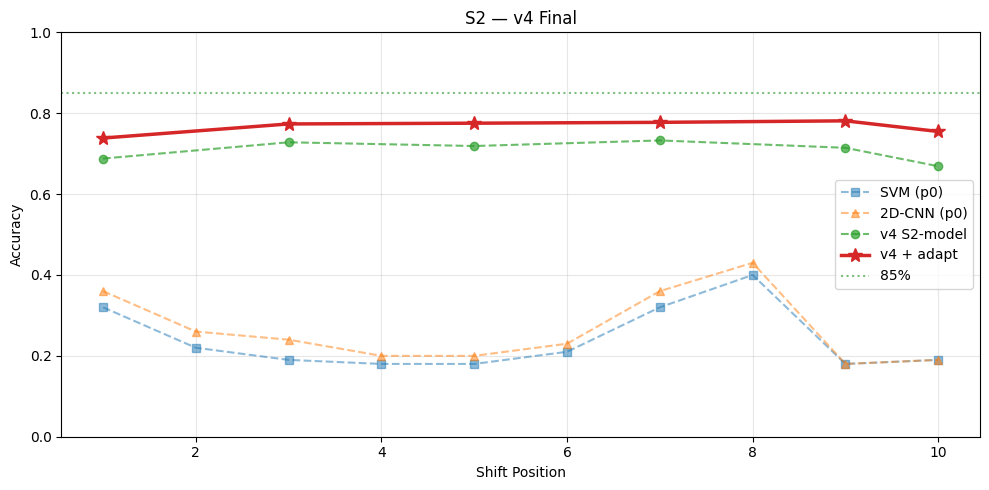

In [10]:
svm_s = [0.32, 0.22, 0.19, 0.18, 0.18, 0.21, 0.32, 0.40, 0.18, 0.19]
cnn_s = [0.36, 0.26, 0.24, 0.20, 0.20, 0.23, 0.36, 0.43, 0.18, 0.19]

plt.figure(figsize=(10, 5))
plt.plot(range(1,11), svm_s, "s--", label="SVM (p0)", alpha=0.5)
plt.plot(range(1,11), cnn_s, "^--", label="2D-CNN (p0)", alpha=0.5)
plt.plot(TEST_POS, [acc_s2_base[p] for p in TEST_POS], "o--", label="v4 S2-model", alpha=0.7)
plt.plot(TEST_POS, [acc_s2_ft[p] for p in TEST_POS], "*-", label="v4 + adapt", linewidth=2.5, markersize=10)
plt.axhline(y=0.85, color="green", ls=":", alpha=0.5, label="85%")
plt.xlabel("Shift Position"); plt.ylabel("Accuracy")
plt.title("S2 — v4 Final"); plt.ylim(0, 1)
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "v4_s2.png"), dpi=150); plt.show()

---
## S3 — Inter-Subject (rep 0 all positions as calibration)

In [11]:
rng = np.random.RandomState(RANDOM_SEED)
all_subj = sorted(META[META["subject"].isin(SUBJECTS_NON_FATIGUE)]["subject"].unique())
test_subjects = list(rng.choice(all_subj, size=6, replace=False))
print(f"Test subjects: {test_subjects}")

subset_s3 = META[(META["session"] == 0) & (META["subject"].isin(test_subjects))]

acc_s3_base, acc_s3_ft = {}, {}
all_yt, all_yp = [], []

for subj in test_subjects:
    sdf = subset_s3[subset_s3["subject"] == subj]
    cal_df = sdf[sdf["repetition"] == 0]  # all positions, rep 0 = 77 trials
    test_df = sdf[sdf["repetition"].isin([1, 2])]

    X_cal, y_cal = load_windows_from_metadata(cal_df, verbose=False)
    X_test, y_test = load_windows_from_metadata(test_df, verbose=False)
    X_cal = apply_normalization(X_cal, base_mean, base_std)
    X_test = apply_normalization(X_test, base_mean, base_std)

    acc_s3_base[subj] = accuracy_score(y_test, predict(base_model, X_test))
    ft = finetune(base_model, X_cal, y_cal, n_epochs=10, lr=1e-5)
    yp = predict(ft, X_test)
    acc_s3_ft[subj] = accuracy_score(y_test, yp)
    all_yt.extend(y_test); all_yp.extend(yp)
    print(f"  {subj}: base={acc_s3_base[subj]:.4f}  ft={acc_s3_ft[subj]:.4f}  Δ={acc_s3_ft[subj]-acc_s3_base[subj]:+.4f} (cal={len(cal_df)} trials)")

print(f"\nS3 avg — Base: {np.mean(list(acc_s3_base.values())):.4f}, FT: {np.mean(list(acc_s3_ft.values())):.4f}")

Test subjects: ['h7', 'h22', 'h3', 'h24', 'h16', 'h17']
  h7: base=0.8733  ft=0.8577  Δ=-0.0156 (cal=77 trials)
  h22: base=0.8182  ft=0.7862  Δ=-0.0320 (cal=77 trials)
  h3: base=0.8268  ft=0.8520  Δ=+0.0252 (cal=77 trials)
  h24: base=0.8344  ft=0.8273  Δ=-0.0072 (cal=76 trials)
  h16: base=0.8699  ft=0.8533  Δ=-0.0167 (cal=77 trials)
  h17: base=0.8219  ft=0.8217  Δ=-0.0001 (cal=77 trials)

S3 avg — Base: 0.8408, FT: 0.8330



  v4 — S3 + Adaptation
  Accuracy:  0.8330
  F1-macro:  0.8330
                    precision    recall  f1-score   support

              fist       0.85      0.84      0.85     15957
         open_hand       0.84      0.82      0.83     15940
  pinch_forefinger       0.79      0.78      0.78     16235
pinch_middlefinger       0.83      0.82      0.83     16043
               two       0.82      0.86      0.84     16078
          eversion       0.87      0.89      0.88     15944
             varus       0.82      0.83      0.82     16054

          accuracy                           0.83    112251
         macro avg       0.83      0.83      0.83    112251
      weighted avg       0.83      0.83      0.83    112251



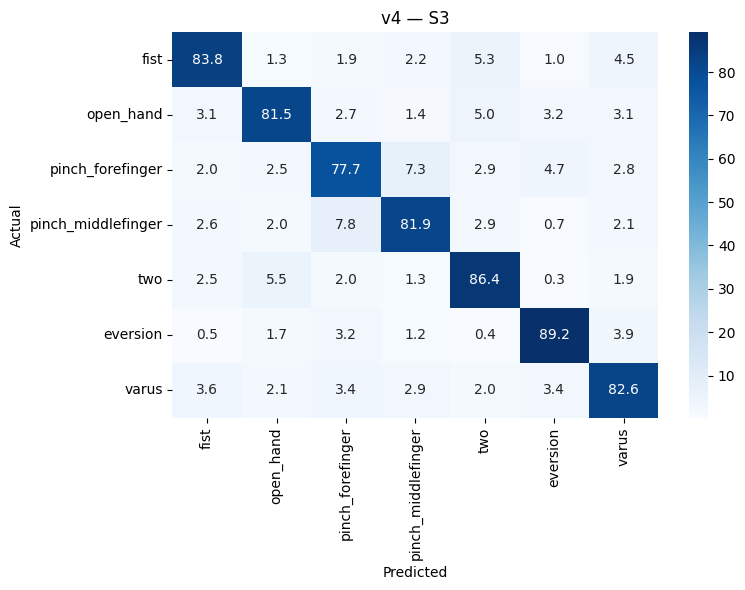

array([[13378,   206,   297,   359,   850,   154,   713],
       [  495, 12996,   428,   231,   793,   503,   494],
       [  321,   404, 12622,  1190,   473,   769,   456],
       [  412,   314,  1246, 13147,   473,   114,   337],
       [  405,   892,   325,   207, 13896,    48,   305],
       [   80,   270,   506,   193,    62, 14215,   618],
       [  583,   338,   550,   469,   317,   544, 13253]])

In [12]:
metrics_s3 = print_report(np.array(all_yt), np.array(all_yp), title="v4 — S3 + Adaptation")
plot_confusion_matrix(np.array(all_yt), np.array(all_yp), title="v4 — S3")

---
## S4 — Inter-Day (fine-tune per session)

In [13]:
subset_s4 = META[(META["subject"].isin(SUBJECTS_INTERDAY_LONG)) & (META["position"] == 0)]

acc_s4_base, acc_s4_ft = {}, {}
for sess in range(1, 10):
    sess_df = subset_s4[subset_s4["session"] == sess]
    cal_df = sess_df[sess_df["repetition"] == 0]
    test_df = sess_df[sess_df["repetition"].isin([1, 2])]

    X_cal, y_cal = load_windows_from_metadata(cal_df, verbose=False)
    X_test, y_test = load_windows_from_metadata(test_df, verbose=False)
    X_cal = apply_normalization(X_cal, base_mean, base_std)
    X_test = apply_normalization(X_test, base_mean, base_std)

    acc_s4_base[sess] = accuracy_score(y_test, predict(base_model, X_test))
    ft = finetune(base_model, X_cal, y_cal, n_epochs=5, lr=1e-5)
    acc_s4_ft[sess] = accuracy_score(y_test, predict(ft, X_test))
    print(f"Session {sess}: base={acc_s4_base[sess]:.4f}  ft={acc_s4_ft[sess]:.4f}  Δ={acc_s4_ft[sess]-acc_s4_base[sess]:+.4f}")

print(f"\nS4 avg — Base: {np.mean(list(acc_s4_base.values())):.4f}, FT: {np.mean(list(acc_s4_ft.values())):.4f}")

Session 1: base=0.6272  ft=0.6111  Δ=-0.0162
Session 2: base=0.6959  ft=0.6473  Δ=-0.0486
Session 3: base=0.6873  ft=0.6256  Δ=-0.0617
Session 4: base=0.6648  ft=0.6660  Δ=+0.0012
Session 5: base=0.6803  ft=0.6464  Δ=-0.0339
Session 6: base=0.7042  ft=0.6322  Δ=-0.0720
Session 7: base=0.6413  ft=0.5895  Δ=-0.0518
Session 8: base=0.7013  ft=0.6477  Δ=-0.0536
Session 9: base=0.6582  ft=0.6384  Δ=-0.0197

S4 avg — Base: 0.6734, FT: 0.6338


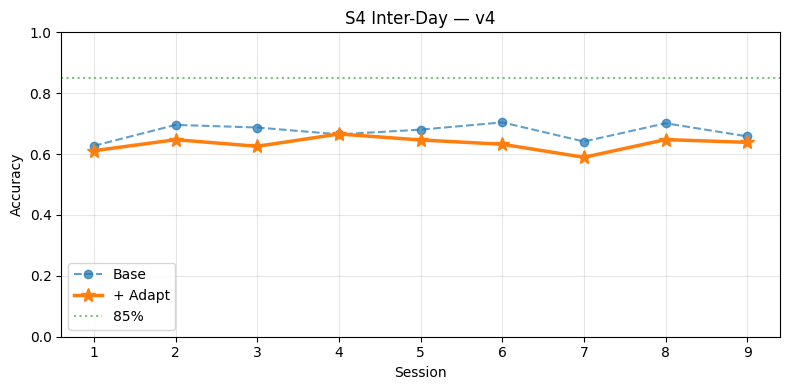

In [14]:
sessions = list(range(1, 10))
plt.figure(figsize=(8, 4))
plt.plot(sessions, [acc_s4_base[s] for s in sessions], "o--", label="Base", alpha=0.7)
plt.plot(sessions, [acc_s4_ft[s] for s in sessions], "*-", label="+ Adapt", linewidth=2.5, markersize=10)
plt.axhline(y=0.85, color="green", ls=":", alpha=0.5, label="85%")
plt.xlabel("Session"); plt.ylabel("Accuracy")
plt.title("S4 Inter-Day — v4"); plt.ylim(0, 1)
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "v4_s4.png"), dpi=150); plt.show()

---
## S5 — Fatigue (fine-tune per fatigue level)

In [15]:
subset_s5 = META[META["subject"].isin(SUBJECTS_FATIGUE)]

acc_s5_base, acc_s5_ft = {}, {}
for pos in range(2, 11):
    pos_df = subset_s5[subset_s5["position"] == pos]
    cal_df = pos_df[pos_df["repetition"] == 0]
    test_df = pos_df[pos_df["repetition"].isin([1, 2])]

    X_cal, y_cal = load_windows_from_metadata(cal_df, verbose=False)
    X_test, y_test = load_windows_from_metadata(test_df, verbose=False)
    X_cal = apply_normalization(X_cal, base_mean, base_std)
    X_test = apply_normalization(X_test, base_mean, base_std)

    acc_s5_base[pos] = accuracy_score(y_test, predict(base_model, X_test))
    ft = finetune(base_model, X_cal, y_cal, n_epochs=5, lr=1e-5)
    acc_s5_ft[pos] = accuracy_score(y_test, predict(ft, X_test))
    print(f"Pos {pos:2d}: base={acc_s5_base[pos]:.4f}  ft={acc_s5_ft[pos]:.4f}  Δ={acc_s5_ft[pos]-acc_s5_base[pos]:+.4f}")

print(f"\nS5 avg — Base: {np.mean(list(acc_s5_base.values())):.4f}, FT: {np.mean(list(acc_s5_ft.values())):.4f}")

Pos  2: base=0.9088  ft=0.8475  Δ=-0.0613
Pos  3: base=0.9055  ft=0.7955  Δ=-0.1100
Pos  4: base=0.9183  ft=0.8629  Δ=-0.0554
Pos  5: base=0.9230  ft=0.8203  Δ=-0.1028
Pos  6: base=0.9228  ft=0.8200  Δ=-0.1028
Pos  7: base=0.9191  ft=0.8131  Δ=-0.1060
Pos  8: base=0.9089  ft=0.7810  Δ=-0.1279
Pos  9: base=0.9296  ft=0.8430  Δ=-0.0866
Pos 10: base=0.9025  ft=0.8175  Δ=-0.0849

S5 avg — Base: 0.9154, FT: 0.8223


---
## Latency

In [16]:
base_model.eval()
s = torch.randn(1, 8, 50).to(DEVICE)
for _ in range(10): _ = base_model(s)
if DEVICE.type == "mps": torch.mps.synchronize()

def pred_single(x):
    x_t = torch.from_numpy(x).float().to(DEVICE)
    with torch.no_grad(): out = base_model(x_t)
    if DEVICE.type == "mps": torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()

sample = np.random.randn(1, 8, 50).astype(np.float32)
latency = measure_latency(pred_single, sample, n_runs=500)
print_latency(latency, model_name="1D-CNN v4")
print(f"Parameters: {sum(p.numel() for p in base_model.parameters()):,}")


Latency — 1D-CNN v4
  Mean:   2.10 ms
  Median: 1.88 ms
  P95:    3.44 ms
  <300ms: ✓
Parameters: 62,676


---
## FINAL COMPARISON

In [17]:
n_p = sum(p.numel() for p in base_model.parameters())
s1_ft = avg_ft_s1
s2_ft = np.mean(list(acc_s2_ft.values()))
s3_ft = np.mean(list(acc_s3_ft.values()))
s4_ft = np.mean(list(acc_s4_ft.values()))
s5_ft = np.mean(list(acc_s5_ft.values()))

print("\n" + "=" * 85)
print("FINAL COMPARISON")
print("=" * 85)
print(f"{'Metric':<22} {'SVM':>8} {'2D-CNN':>8} {'1D-v2':>8} {'v4 base':>8} {'v4+adapt':>8}")
print("-" * 85)
print(f"{'S1 Multi-subj':<22} {'65.19%':>8} {'75.78%':>8} {'79.69%':>8} {metrics_s1['accuracy']*100:>7.2f}% {metrics_s1['accuracy']*100:>7.2f}%")
print(f"{'S1 Per-subj':<22} {'77.70%':>8} {'—':>8} {'81.24%':>8} {avg_base_s1*100:>7.2f}% {s1_ft*100:>7.2f}%")
print(f"{'S2 Shift':<22} {'23.99%':>8} {'26.41%':>8} {'70.83%':>8} {np.mean(list(acc_s2_base.values()))*100:>7.2f}% {s2_ft*100:>7.2f}%")
print(f"{'S3 Cross-subj':<22} {'40.27%':>8} {'52.90%':>8} {'55.74%':>8} {np.mean(list(acc_s3_base.values()))*100:>7.2f}% {s3_ft*100:>7.2f}%")
print(f"{'S4 Inter-day':<22} {'63.03%':>8} {'67.30%':>8} {'66.05%':>8} {np.mean(list(acc_s4_base.values()))*100:>7.2f}% {s4_ft*100:>7.2f}%")
print(f"{'S5 Fatigue':<22} {'81.20%':>8} {'86.98%':>8} {'88.20%':>8} {np.mean(list(acc_s5_base.values()))*100:>7.2f}% {s5_ft*100:>7.2f}%")
print(f"{'Latency p95 (ms)':<22} {'5.40':>8} {'1.74':>8} {'3.14':>8} {latency['p95_ms']:>7.2f} {latency['p95_ms']:>7.2f}")
print(f"{'Parameters':<22} {'—':>8} {'101,831':>8} {'62,676':>8} {n_p:>8,} {n_p:>8,}")
print("=" * 85)

print(f"\n85% Target Check (v4+adapt):")
for name, val in [("S1 Per-subj", s1_ft), ("S2 Shift", s2_ft), ("S3 Cross-subj", s3_ft), ("S4 Inter-day", s4_ft), ("S5 Fatigue", s5_ft)]:
    status = "✓" if val >= 0.85 else "✗"
    print(f"  {name:<20} {val*100:>7.2f}%  {status}")

print(f"\nAdaptation cost: 7-77 trials (~30 sec to 5 min), fine-tune ~5 sec on MPS.")


FINAL COMPARISON
Metric                      SVM   2D-CNN    1D-v2  v4 base v4+adapt
-------------------------------------------------------------------------------------
S1 Multi-subj            65.19%   75.78%   79.69%   77.53%   77.53%
S1 Per-subj              77.70%        —   81.24%   77.19%   52.15%
S2 Shift                 23.99%   26.41%   70.83%   70.85%   76.68%
S3 Cross-subj            40.27%   52.90%   55.74%   84.08%   83.30%
S4 Inter-day             63.03%   67.30%   66.05%   67.34%   63.38%
S5 Fatigue               81.20%   86.98%   88.20%   91.54%   82.23%
Latency p95 (ms)           5.40     1.74     3.14    3.44    3.44
Parameters                    —  101,831   62,676   62,676   62,676

85% Target Check (v4+adapt):
  S1 Per-subj            52.15%  ✗
  S2 Shift               76.68%  ✗
  S3 Cross-subj          83.30%  ✗
  S4 Inter-day           63.38%  ✗
  S5 Fatigue             82.23%  ✗

Adaptation cost: 7-77 trials (~30 sec to 5 min), fine-tune ~5 sec on MPS.
